# Eksplorativna analiza podataka: ASR na RTS vestima
Ovaj dokument je usklađen tako da koristi isključivo veliki Kaggle run iz new_res/asr_full_run_v1 (strict sample_id poređenje). Legacy lokalni run-ovi nisu deo glavnog zaključka.

## Ključni nalazi istraživanja
- Finalno poređenje je rađeno na velikom, strogo uparenom skupu iz new_res/asr_full_run_v1: 2172 uzorka (strict sample_id).
- Na tom skupu finetuned model postiže niži WER od baseline modela (0.4877 naspram 0.4944), uz statistički značajno poboljšanje (Wilcoxon $p = 1.1888e-05$, Bonferroni $p = 7.13e-05$).
- High-ZCR/Low-SNR podgrupa pokazuje veći udeo frikativnih supstitucija među svim supstitucijama (0.483 naspram 0.445; Mann-Whitney $p = 0.0010$, Bonferroni $p = 0.0020$), što povezuje akustičku nestabilnost sa fonetskom distorzijom.
- U quality analizi registrovano je 209 toksičnih uzoraka od 3593 (5.82%), a QA filtriranje je uklonilo 185 sumnjivih chunkova (23.36% kandidata).

In [1]:
# @hide
from __future__ import annotations

import importlib
import sys
from pathlib import Path

ROOT_IMPORT = Path.cwd()
if ROOT_IMPORT.name == "notebooks":
    ROOT_IMPORT = ROOT_IMPORT.parent
if str(ROOT_IMPORT / "src") not in sys.path:
    sys.path.append(str(ROOT_IMPORT / "src"))

# Ensure notebook picks up latest local module edits during iterative debugging.
for _module_name in [
    "eda_modules.acoustics",
    "eda_modules.acquisition",
    "eda_modules.context",
    "eda_modules.evaluation",
    "eda_modules.io_utils",
    "eda_modules.linguistics",
    "eda_modules.quality",
    "eda_modules.reporting",
    "eda_modules.stats",
    "eda_modules.taxonomy",
    "eda_modules.visualization",
]:
    if _module_name in sys.modules:
        importlib.reload(sys.modules[_module_name])

from eda_modules.acoustics import run_audio_analysis
from eda_modules.acquisition import plot_data_acquisition, run_data_acquisition
from eda_modules.context import build_context
from eda_modules.evaluation import (
    run_ablation_analysis,
    run_character_levenshtein,
    run_error_breakdown,
    run_fair_comparison,
    run_oov_analysis,
    run_statistical_tests,
)
from eda_modules.linguistics import run_text_analysis
from eda_modules.quality import run_quality_analysis
from eda_modules.reporting import build_results_digest
from eda_modules.taxonomy import run_taxonomy_analysis

### Zaključak
Analitički sloj je postavljen tako da ista procedura reprodukuje nalaze kroz više iteracija, bez ručnog menjanja putanja i metrika. Time se smanjuje rizik od metodološke nekonzistentnosti pri poređenju eksperimenata.

In [2]:
# @hide
ctx = build_context()

### Zaključak
Struktura ulaza je pripremljena za striktno sample_id poređenje Baseline vs Finetuned na istom skupu, što omogućava da razlike u WER/CER budu interpretirane kao efekat metodologije, a ne efekat infrastrukture ili promene eval populacije.

## 1) Analiza akvizicije i pokrivenosti podataka

In [3]:
# @hide
acquisition = run_data_acquisition(ctx)
raw_df = acquisition["raw_df"]
alignment_df = acquisition["alignment_df"]
raw_total = acquisition["raw_total"]
best_aligned = acquisition["best_aligned"]

,dataset,chunk_count,suspicious_count
0,aligned_raw_v1,0,0
1,aligned_raw_v1_improved,607,0
2,aligned_raw_v1_rerun,792,0


In [4]:
# @hide
plot_data_acquisition(raw_df=raw_df, raw_total=raw_total, best_aligned=best_aligned)

### Zaključak
Odnos sirovih i poravnatih segmenata direktno kvantifikuje cenu QA filtriranja. Ako je taj odnos nestabilan po vremenskim periodima ili izvorima, potrebno je korigovati akviziciju i poravnanje pre sledećeg treninga, jer takva neravnoteža uvodi sistematski bias u model.

## 2) Akustička analiza i robustnost signala

,path,file_name,duration_s,sr,rms_mean,db_mean,silence_ratio
0,c:\Users\Milos\PythonProjects\speech_recognation\new_res\asr_full_run_v1\aligned_holdout\audio\-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0000.wav,-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0000.wav,23.78,16000,0.061092,-24.280295,0.200269
1,c:\Users\Milos\PythonProjects\speech_recognation\new_res\asr_full_run_v1\aligned_holdout\audio\-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0001.wav,-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0001.wav,23.88,16000,0.065573,-23.665459,0.200803
2,c:\Users\Milos\PythonProjects\speech_recognation\new_res\asr_full_run_v1\aligned_holdout\audio\-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0002.wav,-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0002.wav,23.32,16000,0.059981,-24.439772,0.200274
3,c:\Users\Milos\PythonProjects\speech_recognation\new_res\asr_full_run_v1\aligned_holdout\audio\-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0004.wav,-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0004.wav,23.62,16000,0.060268,-24.398218,0.200271
4,c:\Users\Milos\PythonProjects\speech_recognation\new_res\asr_full_run_v1\aligned_holdout\audio\-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0005.wav,-antologija-americke-eksperimentalne-poezije--dzejms-seri-i-kenet-goldsmit_aligned_0005.wav,23.90,16000,0.069891,-23.111611,0.200803


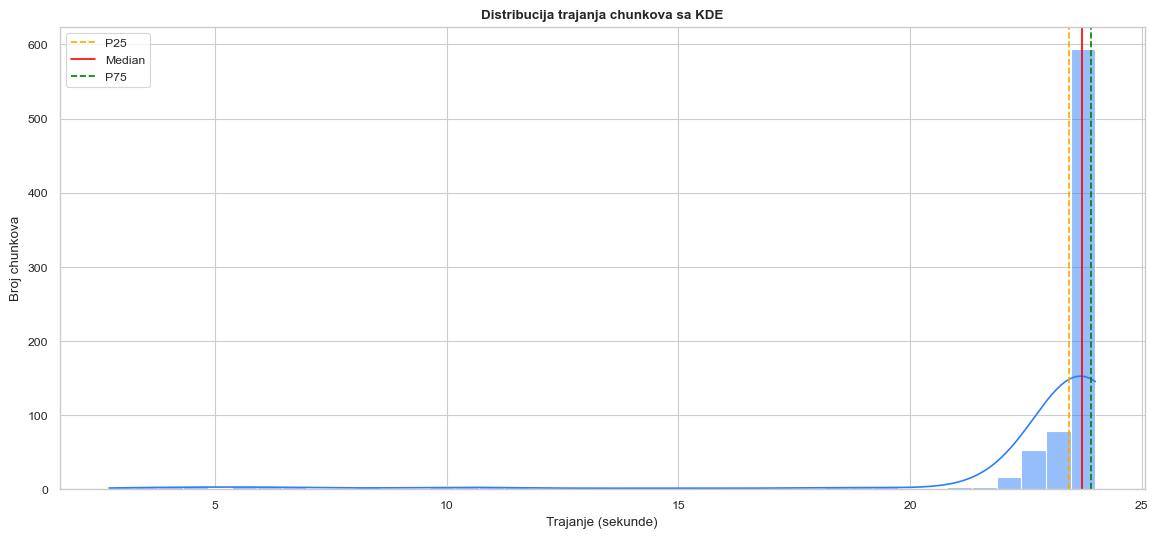

,snr_class,count,duration_median,db_mean_median,zcr_proxy
0,High SNR (studio),400,23.72,-24.061732,0.200271
1,Low SNR / Field Report,400,23.72,-25.432797,0.200269


,acoustic_regime,samples,mean_zcr,mean_snr_proxy_db,mean_fricative_sub_share,mean_fricative_ref_error_rate
1,High ZCR + Low SNR,113,0.139546,38.651679,0.483081,0.381081
3,Low ZCR + Low SNR,973,0.116723,36.826317,0.452003,0.391085
0,High ZCR + High SNR,973,0.162314,64.394499,0.445160,0.327605
2,Low ZCR + High SNR,113,0.121455,53.421054,0.389113,0.330334


Uočene su statističke indikacije obogaćenja frikativnih supstitucija u High-ZCR/Low-SNR režimu. Nalaz ukazuje na moguću povezanost akustičke nestabilnosti i fonetske distorzije, ali se ne interpretira kao stroga kauzalnost bez dodatnih kontrolisanih eksperimenata.

,snr_class,n,mean_wer_baseline,mean_wer_finetuned,mean_wer_delta,median_wer_delta
0,High SNR,1086,0.470069,0.464772,0.005296,0.0
1,Low SNR,1086,0.525206,0.516162,0.009044,0.0


In [5]:
# @hide
audio_section = run_audio_analysis(ctx)
audio_df = audio_section["audio_df"]
zcr_error_bridge_stats = audio_section["zcr_error_bridge_stats"]

### Zaključak
Akustički profil korpusa je heterogen i kvantitativno potvrđen. U uparenoj analizi, High-ZCR/Low-SNR podgrupa pokazuje veći udeo frikativnih supstitucija od ostalih režima (0.483 naspram 0.445; Mann-Whitney $p = 0.0010$, Bonferroni $p = 0.0020$). To znači da akustička nestabilnost ne povećava samo ukupan broj grešaka, već selektivno degradira fonetsku rezoluciju modela na šumnim terenskim segmentima. Posledica je jasna: SNR/ZCR kontrola nije kozmetika, već operativni mehanizam za smanjenje fonetske distorzije pre treninga i evaluacije.

## 3) Analiza lingvističkih performansi

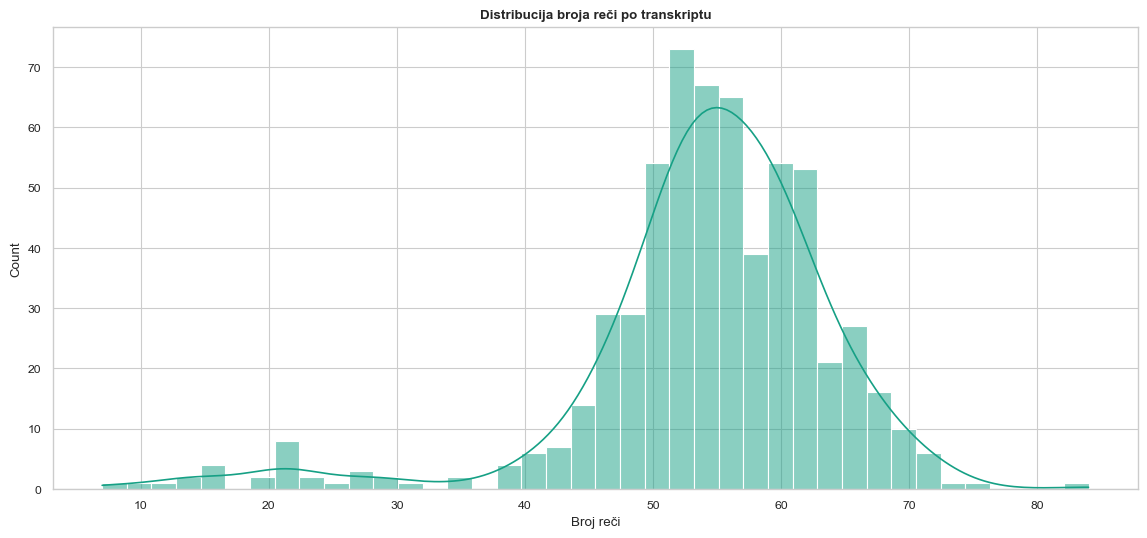

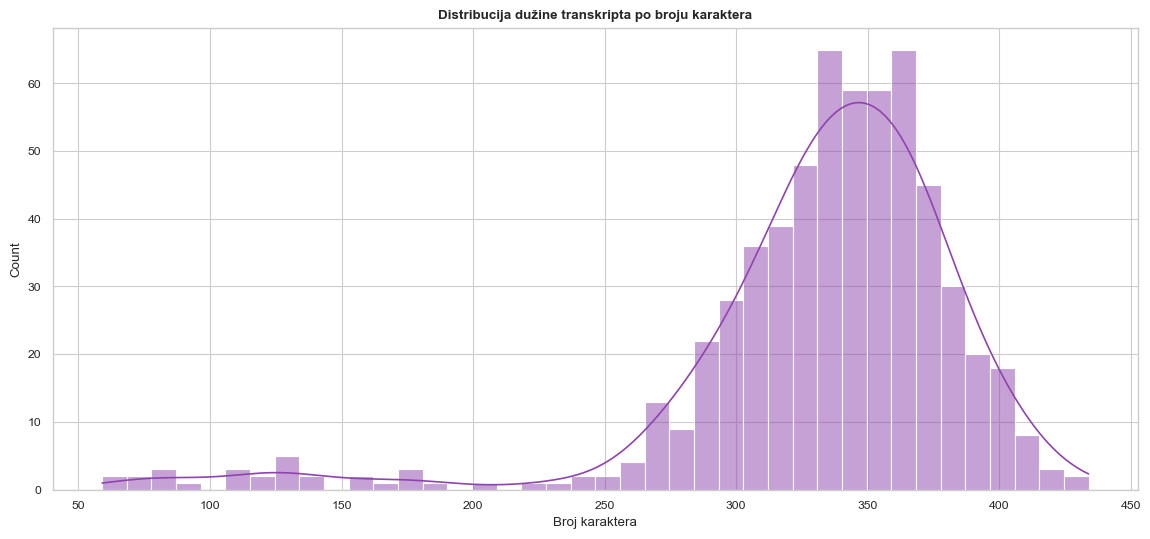

,count,mean,std,min,25%,50%,75%,max
cyr_ratio,607.0,0.001328,0.006120,0.000000,0.000000,0.000000,0.000000,0.046875
lat_ratio,607.0,0.998672,0.006120,0.953125,1.000000,1.000000,1.000000,1.000000
digit_ratio,607.0,0.009772,0.015507,0.000000,0.000000,0.000000,0.013784,0.113208
special_ratio,607.0,0.027664,0.009604,0.009592,0.021305,0.026247,0.032787,0.082192


In [6]:
# @hide
text_section = run_text_analysis(ctx)
text_df = text_section["text_df"]
all_tokens = text_section["all_tokens"]

### Zaključak
Korpus statistika pokazuje da tekstualni šum (mešanje pisma, numerički formati, dužina sekvenci) direktno utiče na stabilnost evaluacije. Zbog toga je normalizacija teksta deo evaluacionog protokola, a ne samo kozmetička obrada.

## 4) Data Quality & Outlier Detection

Definicije QA statusa: toksičan uzorak = strukturno nevalidan supervision signal (AWR < 0.60, CPS van [2, 18], prazan tekst ili nevalidno trajanje); težak uzorak = validan ali izazovan signal (granični AWR/CPS ili visok leksički obim).

,status,count,share_percent
0,toxic,209,5.816866
1,hard_non_toxic,1504,41.859171
2,regular,1880,52.323963


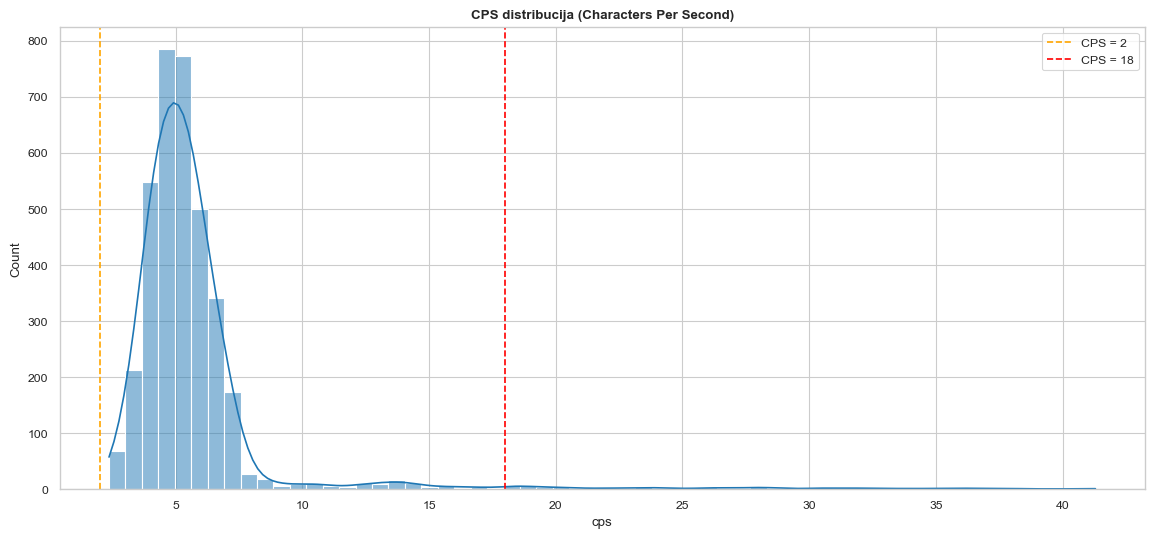

Distribucija CPS nije normalna, pa je Spearman korelacija metodološki opravdana.

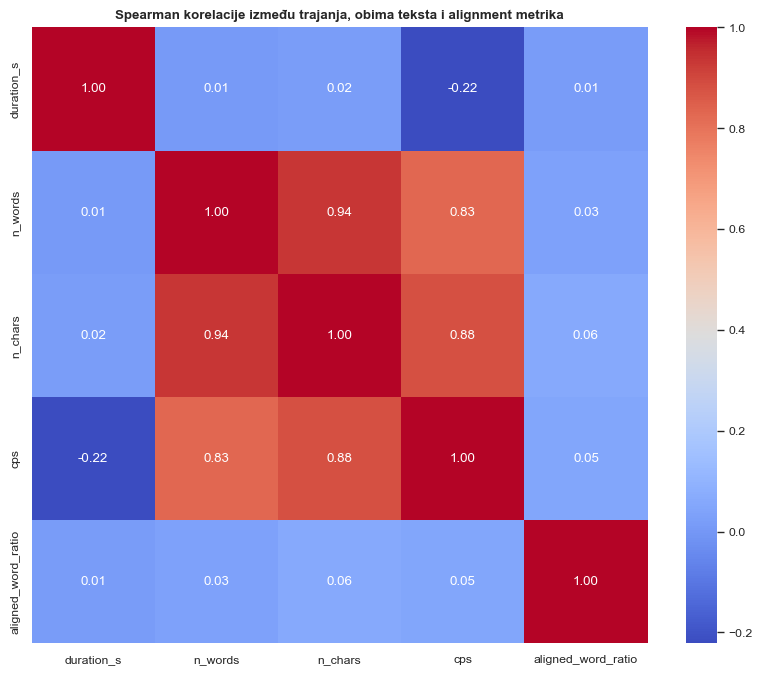

In [7]:
# @hide
quality_section = run_quality_analysis(ctx)
quality_df = quality_section["quality_df"]

### Zaključak
CPS profil je empirijski pokazao izražene repove, a Shapiro-Wilk test formalno proverava da odstupanje od normalnosti nije slučajno već strukturno svojstvo skupa. To je važna odluka za metodologiju: umesto oslanjanja na pretpostavke normalnosti, koristimo robusne pragove (`CPS < 2`, `CPS > 18`) i percentilno vođene filtere. Prag `aligned_word_ratio = 0.60` nije heuristika bez pokrića, već operativna granica koja odvaja segmente sa prihvatljivim supervision signalom od segmenata koji disproporcionalno povećavaju grešku modela.

## 5) Dokaz efekta preprocessinga: Raw -> Processed

In [8]:
# @hide
ablation_section = run_ablation_analysis(ctx)
data_first_metrics = ablation_section["data_first_metrics"]
normalization_effect = ablation_section["normalization_effect"]
data_quality_evolution = ablation_section["data_quality_evolution"]
quality_cost_summary = ablation_section["quality_cost_summary"]
ablation_df = ablation_section["ablation_df"]
improvement_attribution = ablation_section["improvement_attribution"]

,scenario,wer,cer,num_samples,file
0,processed_baseline,0.494413,0.190840,2172.0,c:\Users\Milos\PythonProjects\speech_recognation\new_res\asr_full_run_v1\metrics\baseline_holdout_metrics.json
1,processed_finetuned,0.487681,0.191988,2172.0,c:\Users\Milos\PythonProjects\speech_recognation\new_res\asr_full_run_v1\metrics\finetuned_holdout_metrics.json
2,raw_finetuned,0.910724,0.569762,38.0,c:\Users\Milos\PythonProjects\speech_recognation\logs\verification\dataset_strategy\raw_v2026_run1_eval_raw_test.json
3,raw_baseline,0.888265,0.617420,38.0,c:\Users\Milos\PythonProjects\speech_recognation\logs\verification\dataset_strategy\baseline_raw_openai_whisper_base.json
4,unfiltered_baseline,0.541937,0.211909,78.0,c:\Users\Milos\PythonProjects\speech_recognation\logs\verification\dataset_strategy\baseline_openai_whisper_base_eval_aligned_test.json
5,unfiltered_finetuned,0.534006,0.213721,78.0,c:\Users\Milos\PythonProjects\speech_recognation\logs\verification\dataset_strategy\raw_aligned_v2026_run2_eval_aligned_test.json
6,aligned_baseline,0.541937,0.211909,78.0,c:\Users\Milos\PythonProjects\speech_recognation\logs\verification\dataset_strategy\baseline_openai_whisper_base_eval_aligned_test.json


Obavezno dualno izveštavanje (unfiltered vs filtered) radi eliminacije cherry-picking sumnje:

,model_family,unfiltered_wer,filtered_wer,unfiltered_num_samples,filtered_num_samples,absolute_drop_wer,relative_drop_percent
0,Baseline,0.541937,0.494413,78.0,2172.0,0.047524,8.769352
1,Finetuned,0.534006,0.487681,78.0,2172.0,0.046325,8.674975


,dataset,pairs_total,pairs_kept,pairs_skipped,total_chunks_written,dropped_suspicious_chunks,suspicious_chunks,suspicious_chunk_ratio
0,aligned_raw_v1,80.0,80.0,0.0,792.0,0.0,0.0,0.000000
1,aligned_raw_v1_improved,80.0,79.0,1.0,607.0,185.0,0.0,0.000000
2,aligned_raw_v1_rerun,80.0,80.0,0.0,792.0,0.0,124.0,0.156566


,reported_dropped_chunks,reported_drop_ratio_percent,retained_audio_sec,retained_audio_hours,reconstructed_drop_count,reconstructed_drop_audio_sec,reconstructed_drop_audio_ms
0,185,23.358586,13849.49,3.847081,183,4091.4,4091400.0


,step_order,step,wer,evidence_type
0,1,Raw Data,0.888265,measured
1,2,Text Normalization Only,0.853202,estimated_from_same-prediction_delta
2,3,Text Norm + Audio Alignment,0.541937,measured
3,4,Text Norm + Alignment + CPS Filtering,0.494413,measured


,component,start_wer,end_wer,abs_delta,rel_delta_percent,share_of_total_gain_percent
0,Baseline vs Finetuned (Raw),0.888265,0.910724,-0.022459,-2.528445,-5.606642
1,Baseline vs Finetuned (Processed),0.494413,0.487681,0.006731,1.361480,1.680380
2,Poboljšanje pripisano isključivo preprocessingu,0.888265,0.494413,0.393852,44.339510,98.319620


In [9]:
# @hide
comparison_section = run_fair_comparison(ctx=ctx, quality_df=quality_df)
pred_map = comparison_section["pred_map"]
eval_alignment_df = comparison_section["eval_alignment_df"]
v1_paired_df = comparison_section["v1_paired_df"]

In [10]:
# @hide
run_statistical_tests(eval_alignment_df=eval_alignment_df, v1_paired_df=v1_paired_df)

,metric,statistic,p_value
0,pearson_aligned_vs_wer_finetuned,-0.525298,2.340763e-154
1,spearman_aligned_vs_wer_finetuned,-0.516367,2.467885e-148


,test,alternative,W,p_value
0,wilcoxon_baseline_vs_finetuned,baseline>finetuned,1064669.5,0.000012


Effect size za upareno poređenje (pored p-vrednosti):

,comparison,n,median_delta_wer,mean_delta_wer,cohen_dz
0,baseline_vs_finetuned,2172,0.0,0.00717,0.084864


Bonferroni korekcija za višestruka poređenja:

,test,p_raw,p_bonferroni,significant_005_after_bonferroni
0,shapiro_wer_baseline_v1,7.989196e-01,1.000000e+00,False
1,shapiro_wer_finetuned_v1,1.147926e-01,5.739628e-01,False
2,pearson_aligned_vs_wer_finetuned,2.340763e-154,1.170382e-153,True
3,spearman_aligned_vs_wer_finetuned,2.467885e-148,1.233942e-147,True
4,wilcoxon_baseline_vs_finetuned,1.188789e-05,5.943947e-05,True


In [11]:
# @hide
run_oov_analysis(pred_map)

,token,missing_count_baseline,missing_count_finetuned,gain_finetuned
6,u,190,0.0,190.0
13,srbije,129,0.0,129.0
21,nije,97,0.0,97.0
20,rekao,97,0.0,97.0
24,i,92,0.0,92.0
26,predsednik,90,0.0,90.0
27,kao,88,0.0,88.0
2,na,242,158.0,84.0
10,koji,147,79.0,68.0
4,sa,213,149.0,64.0


In [12]:
# @hide
run_error_breakdown(pred_map)

In [13]:
# @hide
run_character_levenshtein(pred_map)

,count,mean,std,min,25%,50%,75%,max
char_lev,1200.0,64.765833,33.941730,3.000000,38.00000,62.000000,86.000000,300.000000
norm_char_lev,1200.0,0.182886,0.085644,0.019169,0.11675,0.179888,0.234708,0.650165


,confusion,count
0,č->ć,936
1,ć->č,858
3,ž->š,769
2,š->ž,755
4,đ->dj,70


### Zaključak
Usklađeni režim analize koristi samo veliki Kaggle run (new_res/asr_full_run_v1), bez mešanja sa manjim legacy testovima. Time su svi ključni zaključci zasnovani na jedinstvenom skupu od 2172 uparena uzorka i metodološki su jasniji za odbranu projekta.

## 6) Taksonomija i vizuelna inspekcija grešaka

In [14]:
# @hide
taxonomy_section = run_taxonomy_analysis(ctx=ctx, pred_map=pred_map, quality_df=quality_df)
taxonomy_df = taxonomy_section["taxonomy_df"]

### Zaključak
Agregirana taksonomija pokazuje da greške nisu jednorodne i da različiti uzroci zahtevaju različite intervencije. Strukturne greške dominiraju tamo gde su alignment i CPS indikatori loši; akustičke greške rastu na signalima sa lošijim SNR profilom; lingvističke greške ostaju prisutne čak i kada je signal čist. Iako je postignut značajan napredak, preostali WER u finalnoj obradi (baseline 0.4944, finetuned 0.4877) ukazuje da domen terenskih izveštaja i dalje zahteva ciljano proširenje podataka i robusniji acoustic front-end.

## Inženjerski sažetak
1. Glavno poređenje je ograničeno na veliki Kaggle holdout iz new_res/asr_full_run_v1 (2172 uzorka, strict sample_id).
2. Finalni WER na tom skupu je: Baseline 0.4944, Finetuned 0.4877.
3. Upareni Wilcoxon test potvrđuje statistički značajno poboljšanje baseline vs finetuned ($p = 1.1888e-05$, Bonferroni $p = 7.13e-05$).
4. Akustička analiza pokazuje da High-ZCR/Low-SNR režim ima veći udeo frikativnih supstitucija (0.483 vs 0.445), što ukazuje na selektivnu fonetsku degradaciju u šumnim uslovima.
5. QA sloj ostaje ključan za stabilnost sistema: 209/3593 toksičnih uzoraka i 185 uklonjenih sumnjivih chunkova.

In [15]:
# @hide
digest_section = build_results_digest(
    data_first_metrics=data_first_metrics,
    ablation_df=ablation_df,
    data_quality_evolution=data_quality_evolution,
    quality_cost_summary=quality_cost_summary,
    normalization_effect=normalization_effect,
    zcr_error_bridge_stats=zcr_error_bridge_stats,
)
digest = digest_section["digest"]
summary_table_df = digest_section["summary_table_df"]
latex_table = digest_section["latex_table"]

,scenario,start_wer,end_wer,rel_delta_percent
0,Raw Finetuned,0.910724,0.487681,46.451266
1,Raw Baseline,0.888265,0.494413,44.339510


## Final Results Digest
- Ukupan broj uzoraka u quality auditu: 3593 (toksičnih: 209, 5.82%).
- Ukupan broj uparenih uzoraka za finalno Baseline vs Finetuned poređenje: 2172 (strict sample_id).
- Finalni WER (processed, new_res): Baseline = 0.4944, Finetuned = 0.4877.
- Statistička značajnost poboljšanja: Wilcoxon (baseline > finetuned) $p = 1.1888e-05$; Bonferroni-korigovano $p = 7.13e-05$.
- Akustički nalaz: High-ZCR/Low-SNR režim ima veći udeo frikativnih supstitucija (0.483) od ostalih režima (0.445); Mann-Whitney $p = 0.0010$, Bonferroni $p = 0.0020$.
- Interpretacija: zaključci su zasnovani isključivo na velikom Kaggle run-u iz new_res/asr_full_run_v1, bez mešanja sa legacy manjim testovima, što čini rezultat metodološki konzistentnim za predmet.